# Results

In this file you can find an explanation of the experiments I did and their results.

## Methodology

I first used the [huggingFace transformer library](https://github.com/huggingface/transformers) to check the graphormer implementation out for both training loop and LoRA. Aftewards I implemented my own training and evaluation loop, and my own LoRA adapter adaptation. Full fine-tuning took around 1h per epoch. Fine-tuning with LoRA took around 25m per epoch.
- **Model**: The model in question is the [Graphormer](https://graphormer.readthedocs.io/en/latest/), a model used for graph regression and classification tasks.
- **Hyperparameters**: I always used default hyperparameters for the model and dataset in question taken from the [original work](https://arxiv.org/pdf/2106.05234). However, there aren't many hyperparameters other than the usual ones for the transformer architecture. This model didn't introduced any new hyperparameters, and for the optimization and scheduling they used also standard ones. I didn't used any warm-up steps for the training. I used **8 epochs** as the paper said and **batch size 64**. For LoRA I used `r = 16`, layers `q` and `k`, `v`, `o`. Learning rate was a tricky one to tune. I had to implement a scheduler because I got lots of nans in the training. After tuning I used a max. learning rate of `2e-4` (as the paper said) for the full model and `2e-3` for the LoRA experiments. I didn't have enough time to do a full hyperparameter search for LoRA, so these values might not be optimal. 
- **Dataset**: The dataset used was OGBG-MolHIV. Even though the dataset might seem medium-sized, all the metadata that the graphormer needs makes it from ~180MB to ~40GB of size in disk after extracting the needed data for the graphormer, which made it hard to train in a laptop.   
- **Metric**: The metric used was the **ROC-AUC**

The main difference in this evaluation and the paper's is that I didn't used [FLAG](https://arxiv.org/pdf/2010.09891), which is a well-known technique for graph-data augmentation. 

## Results

HF Full: 0.6640 (from ./graph-classification/full/molhiv/checkpoint-2056)
HF LoRA: 0.5000 (from ./graph-classification/lora/molhiv/checkpoint-2056)
Own Code Full: 0.6637 (from ./graph-classification/own_code/full_b_64/molhiv/checkpoint-epoch-4)
Own Code Regularized: 0.6470 (from ./graph-classification/own_code/regularized/molhiv/checkpoint-epoch-7)
Own Code LoRA: 0.6823 (from ./graph-classification/own_code/lora/molhiv/checkpoint-epoch-4)

Plot saved as 'best_roc_auc_comparison.png'


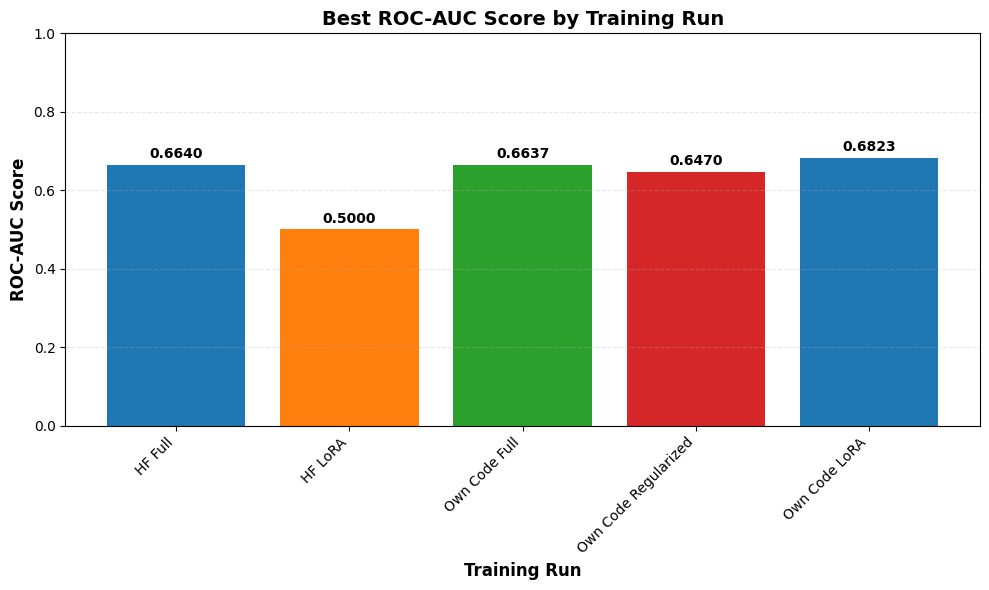

In [1]:
from plot_best_roc_auc import main

main()